In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from pathlib import Path

https://www.kaggle.com/datasets/hcavsi/cicids2017-dataset?

In [3]:
root=Path('data')
root.mkdir(exist_ok=True)
path= root / 'CICIDS2017.csv'

In [4]:
data=pd.read_csv(path)
data

,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Std,label_num
0,6.0,6.000000,0.00000,0.0,0
1,6.0,6.000000,0.00000,0.0,0
2,6.0,6.000000,0.00000,0.0,0
3,6.0,6.000000,0.00000,0.0,0
4,6.0,6.000000,0.00000,0.0,0
...,...,...,...,...,...
2672992,0.0,0.000000,0.00000,0.0,0
2672993,6.0,6.000000,0.00000,0.0,0
2672994,0.0,0.000000,0.00000,0.0,0
2672995,148.0,49.333333,85.44784,0.0,0


In [5]:
data.groupby(data['label_num'])['label_num'].unique()

label_num
0      [0]
1      [1]
2      [2]
3      [3]
4      [4]
5      [5]
6      [6]
7      [7]
8      [8]
9      [9]
10    [10]
11    [11]
Name: label_num, dtype: object

In [6]:
label_map = {
    0: "BENIGN",
    1: "Bot",
    2: "DDoS",
    3: "DoS Hulk",
    4: "DoS GoldenEye",
    5: "DoS Slowloris",
    6: "DoS Slowhttptest",
    7: "FTP-Patator",
    8: "PortScan",
    9: "SSH-Patator",
    10: "Web Attack",
    11: "Infiltration"
}

In [7]:
label_map = {
    0: "BENIGN",
    1: "Bot",
    2: "DoS Hulk",
    3: "DoS GoldenEye",
    4: "DoS Slowloris",
    5: "DoS Slowhttptest",
    6: "FTP-Patator",
    7: "PortScan",
    8: "SSH-Patator"
}

In [8]:
data['label_num'].value_counts().sort_index()

label_num
0     2203723
1      231073
2      158930
3       41835
4       10293
5        7938
6        5897
7        5796
8        5499
9        1966
10         36
11         11
Name: count, dtype: int64

In [9]:
df_bal = data.groupby('label_num', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 10000), random_state=42)).groupby('label_num').filter(lambda x: len(x) >= 1966)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_19992\3459463498.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_bal = data.groupby('label_num', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 10000), random_state=42)).groupby('label_num').filter(lambda x: len(x) >= 1966)


In [10]:
df_bal = df_bal[df_bal["label_num"] != 2].copy()

df_bal["label_num"] = df_bal["label_num"].apply(lambda x: x - 1 if x > 2 else x)

In [11]:
df_bal

,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Std,label_num
1826464,2.0,2.00,0.000000,0.000000,0
2670755,35.0,35.00,0.000000,0.000000,0
1456403,6.0,6.00,0.000000,0.000000,0
993938,47.0,47.00,0.000000,0.000000,0
2142280,46.0,46.00,0.000000,0.000000,0
...,...,...,...,...,...
2082998,6.0,6.00,0.000000,0.000000,8
2084164,198.0,52.50,97.041228,72.231111,8
2081026,195.0,51.75,95.541876,72.231111,8
2092038,6.0,6.00,0.000000,0.000000,8


In [12]:
df_bal['label_num'].value_counts().sort_index()

label_num
0    10000
1    10000
2    10000
3    10000
4     7938
5     5897
6     5796
7     5499
8     1966
Name: count, dtype: int64

In [13]:
data=df_bal

In [14]:
data

,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Std,label_num
1826464,2.0,2.00,0.000000,0.000000,0
2670755,35.0,35.00,0.000000,0.000000,0
1456403,6.0,6.00,0.000000,0.000000,0
993938,47.0,47.00,0.000000,0.000000,0
2142280,46.0,46.00,0.000000,0.000000,0
...,...,...,...,...,...
2082998,6.0,6.00,0.000000,0.000000,8
2084164,198.0,52.50,97.041228,72.231111,8
2081026,195.0,51.75,95.541876,72.231111,8
2092038,6.0,6.00,0.000000,0.000000,8


<Axes: >

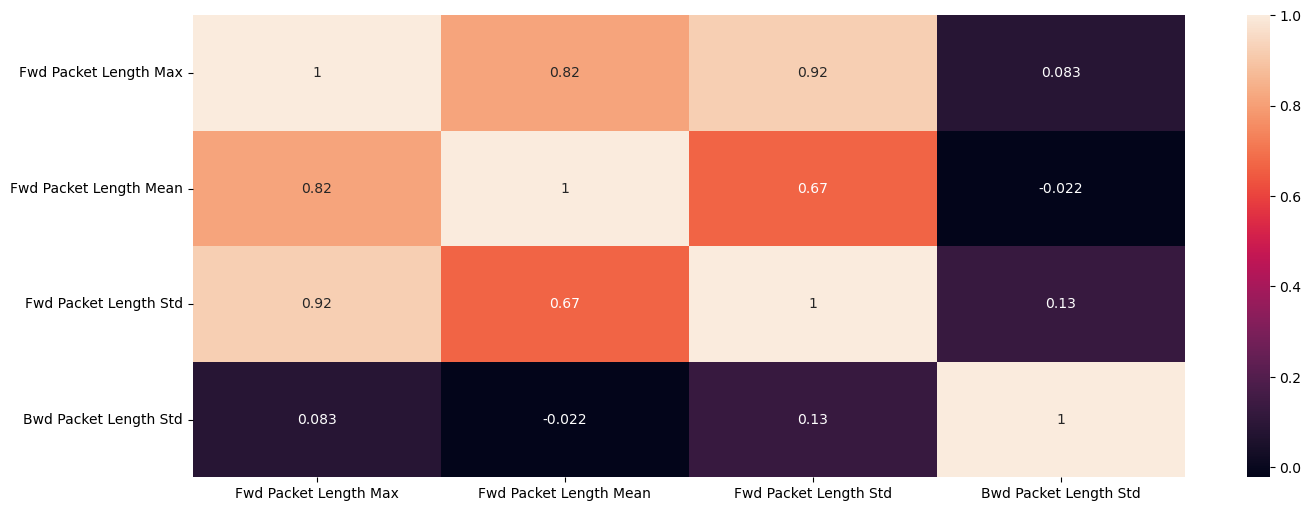

In [15]:
plt.figure(figsize=(16,6))
sns.heatmap(data.drop(['label_num'],axis=1).corr(),annot=True)
#plt.savefig("heatmap.jpg", dpi=1000, bbox_inches="tight")

CPU times: total: 42.1 s
Wall time: 35.5 s


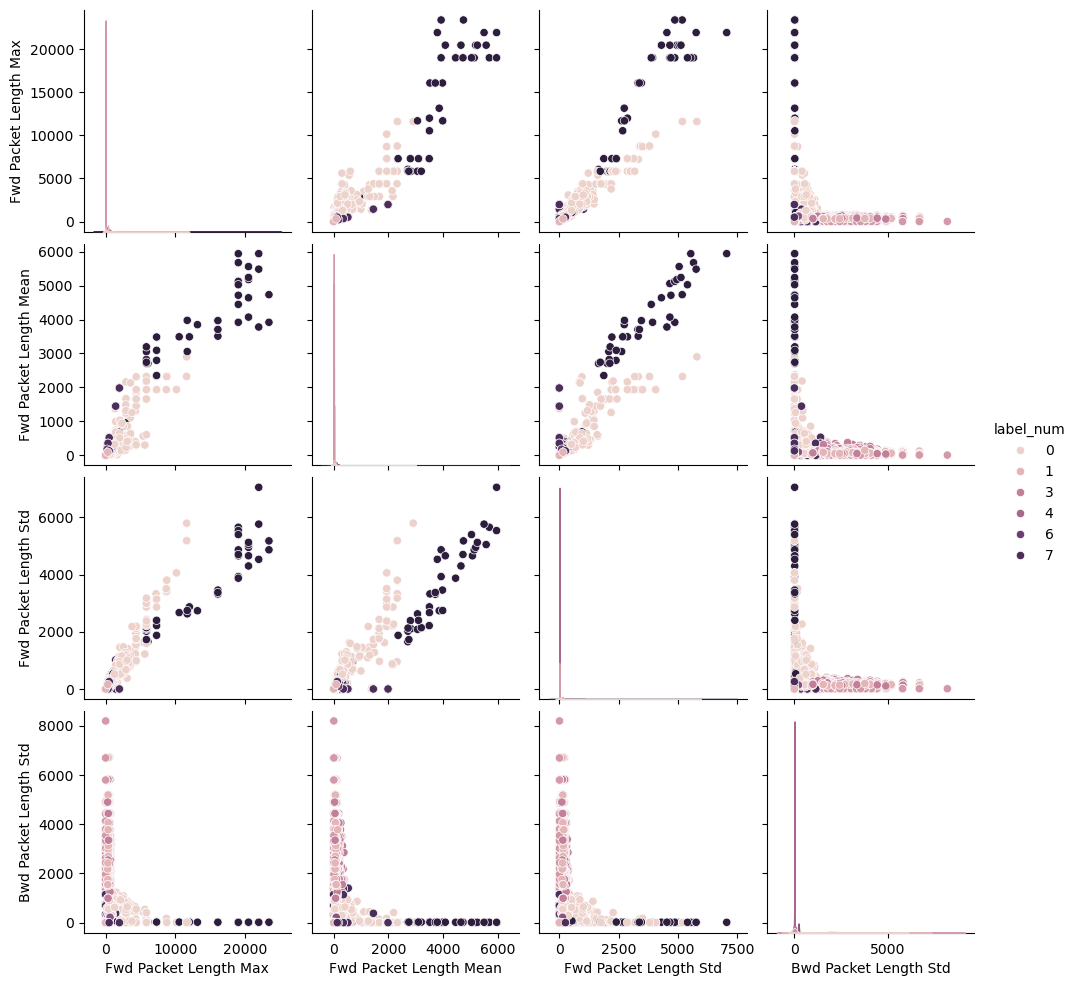

In [16]:
%%time
sns.pairplot(data.sample(n=50000, random_state=42),hue='label_num')

features = data.drop(['label_num'], axis=1).columns

for feature in features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=data,x=feature,fill=True ,hue='label_num')
    plt.show()

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [18]:
features=data.drop(['label_num'],axis=1)
features

,Fwd Packet Length Max,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Std
1826464,2.0,2.00,0.000000,0.000000
2670755,35.0,35.00,0.000000,0.000000
1456403,6.0,6.00,0.000000,0.000000
993938,47.0,47.00,0.000000,0.000000
2142280,46.0,46.00,0.000000,0.000000
...,...,...,...,...
2082998,6.0,6.00,0.000000,0.000000
2084164,198.0,52.50,97.041228,72.231111
2081026,195.0,51.75,95.541876,72.231111
2092038,6.0,6.00,0.000000,0.000000


In [19]:
target=pd.DataFrame(data.label_num)
target

,label_num
1826464,0
2670755,0
1456403,0
993938,0
2142280,0
...,...
2082998,8
2084164,8
2081026,8
2092038,8


In [20]:
xtrain, xtest, ytrain, ytest = train_test_split(features, target, test_size=0.2, random_state=42)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [22]:
import joblib
import warnings

In [23]:
model_results = pd.DataFrame(columns=[
"Model","Train_Acc","Test_Acc",
"Train_Prec","Test_Prec",
"Train_Rec","Test_Rec",
"Train_F1","Test_F1" ])

In [24]:
def clasicalmodels(model,model_name,xtrain=xtrain,ytrain=ytrain,xtest=xtest,ytest=ytest):
    warnings.filterwarnings('ignore')
    model.fit(xtrain, ytrain)
    warnings.filterwarnings('ignore')
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    print(model,':')

    tr_acc = accuracy_score(ytrain, ypred_train)
    te_acc = accuracy_score(ytest, ypred_test)
    tr_p = precision_score(ytrain, ypred_train, average="weighted")
    te_p = precision_score(ytest, ypred_test, average="weighted")
    tr_r = recall_score(ytrain, ypred_train, average="weighted")
    te_r = recall_score(ytest, ypred_test, average="weighted")
    tr_f = f1_score(ytrain, ypred_train, average="weighted")
    te_f = f1_score(ytest, ypred_test, average="weighted")
    
    print(f"Train Accuracy : {tr_acc:.4f}")
    print(f"Test  Accuracy : {te_acc:.4f}")
    print(f"Train Precision: {tr_p:.4f}")
    print(f"Test  Precision: {te_p:.4f}")
    print(f"Train Recall   : {tr_r:.4f}")
    print(f"Test  Recall   : {te_r:.4f}")    
    print(f"Train F1 Score : {tr_f:.4f}")
    print(f"Test  F1 Score : {te_f:.4f}")

    model_results.loc[len(model_results)] = [model_name,tr_acc,te_acc,tr_p, te_p, tr_r, te_r, tr_f, te_f]

    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    sns.heatmap(confusion_matrix(ytrain, ypred_train),annot=True, fmt='d', ax=axes[0], cmap="Blues", cbar=False)
    axes[0].set_title("Train Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    sns.heatmap(confusion_matrix(ytest, ypred_test),annot=True, fmt='d', ax=axes[1], cmap="Blues", cbar=False)
    axes[1].set_title("Test Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.show()
        
    from pathlib import Path
    root=Path("models")
    root.mkdir(exist_ok=True)
    path = root / f"{str(model.__class__.__name__)}.pkl"
    joblib.dump(model, path)

    return model
        

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,
                       random_state=42) :
Train Accuracy : 0.6879
Test  Accuracy : 0.6867
Train Precision: 0.7734
Test  Precision: 0.7723
Train Recall   : 0.6879
Test  Recall   : 0.6867
Train F1 Score : 0.6784
Test  F1 Score : 0.6775


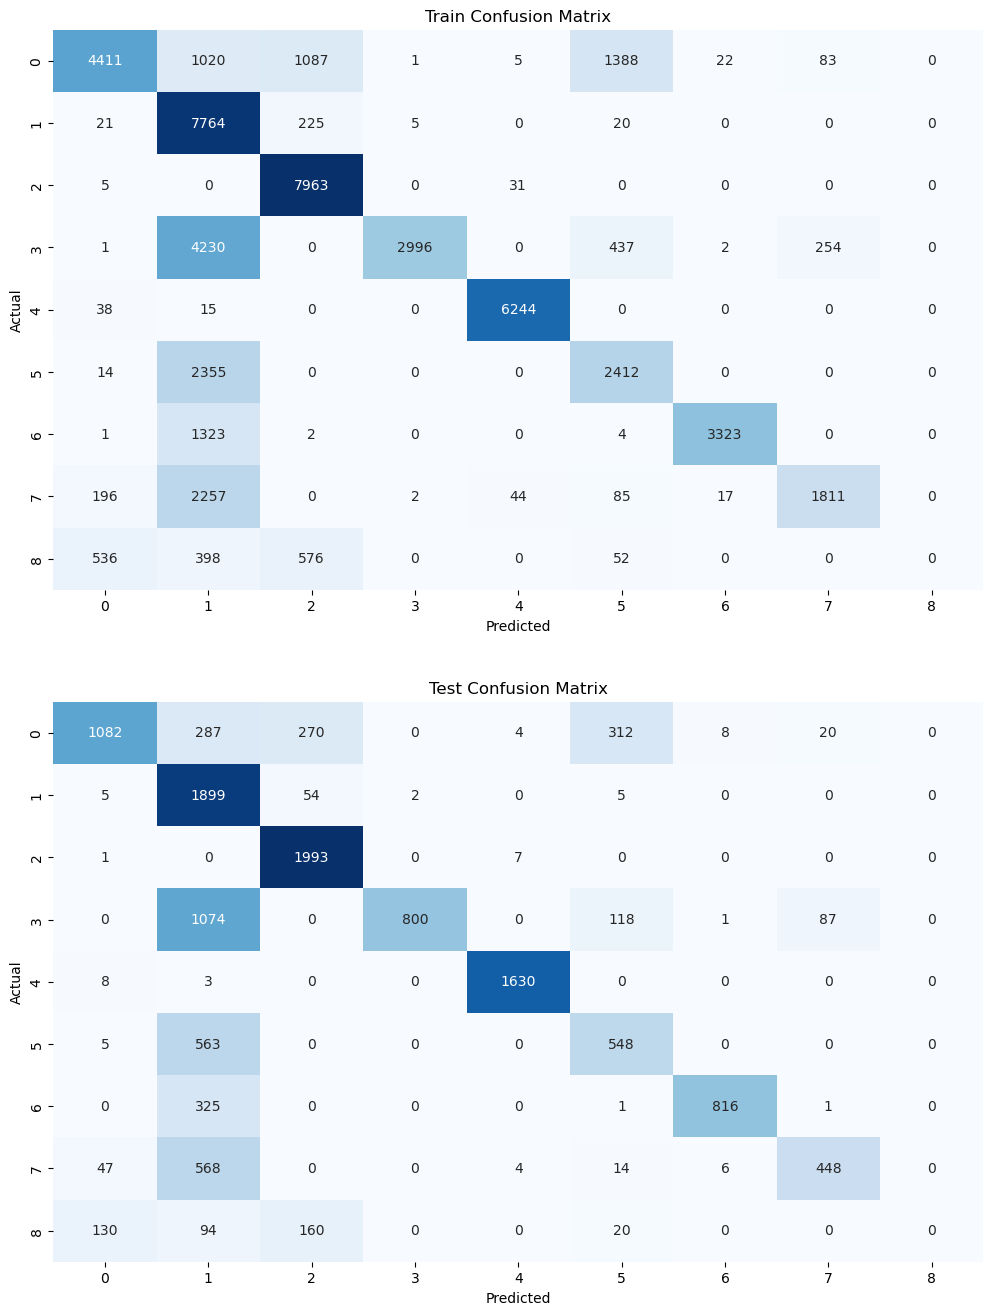

CPU times: total: 562 ms
Wall time: 576 ms


In [25]:
%%time
# DecisionTreeClassifier
decitree=clasicalmodels(DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=2,random_state=42),model_name='DTC')

RandomForestClassifier(n_estimators=18, random_state=86) :
Train Accuracy : 0.7901
Test  Accuracy : 0.7776
Train Precision: 0.9105
Test  Precision: 0.8990
Train Recall   : 0.7901
Test  Recall   : 0.7776
Train F1 Score : 0.8109
Test  F1 Score : 0.7984


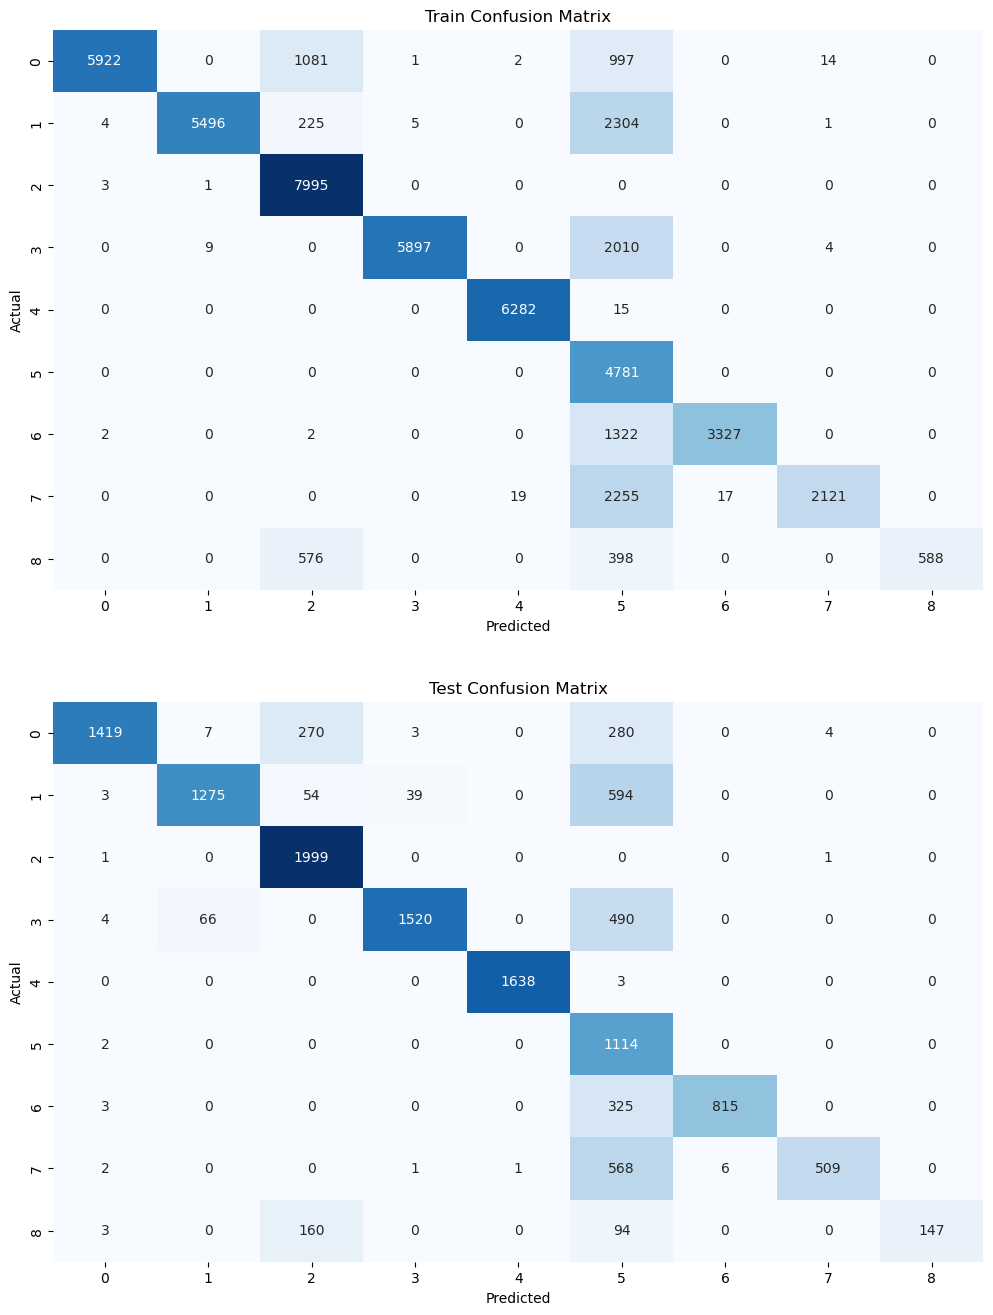

CPU times: total: 1.22 s
Wall time: 1.22 s


In [26]:
%%time
# RandomForestClassifier
warnings.filterwarnings('ignore')
ranfor=clasicalmodels(RandomForestClassifier(n_estimators=18,random_state=86),model_name='RFC')

LogisticRegression(max_iter=5000, random_state=86) :
Train Accuracy : 0.4865
Test  Accuracy : 0.4889
Train Precision: 0.6668
Test  Precision: 0.6627
Train Recall   : 0.4865
Test  Recall   : 0.4889
Train F1 Score : 0.4850
Test  F1 Score : 0.4857


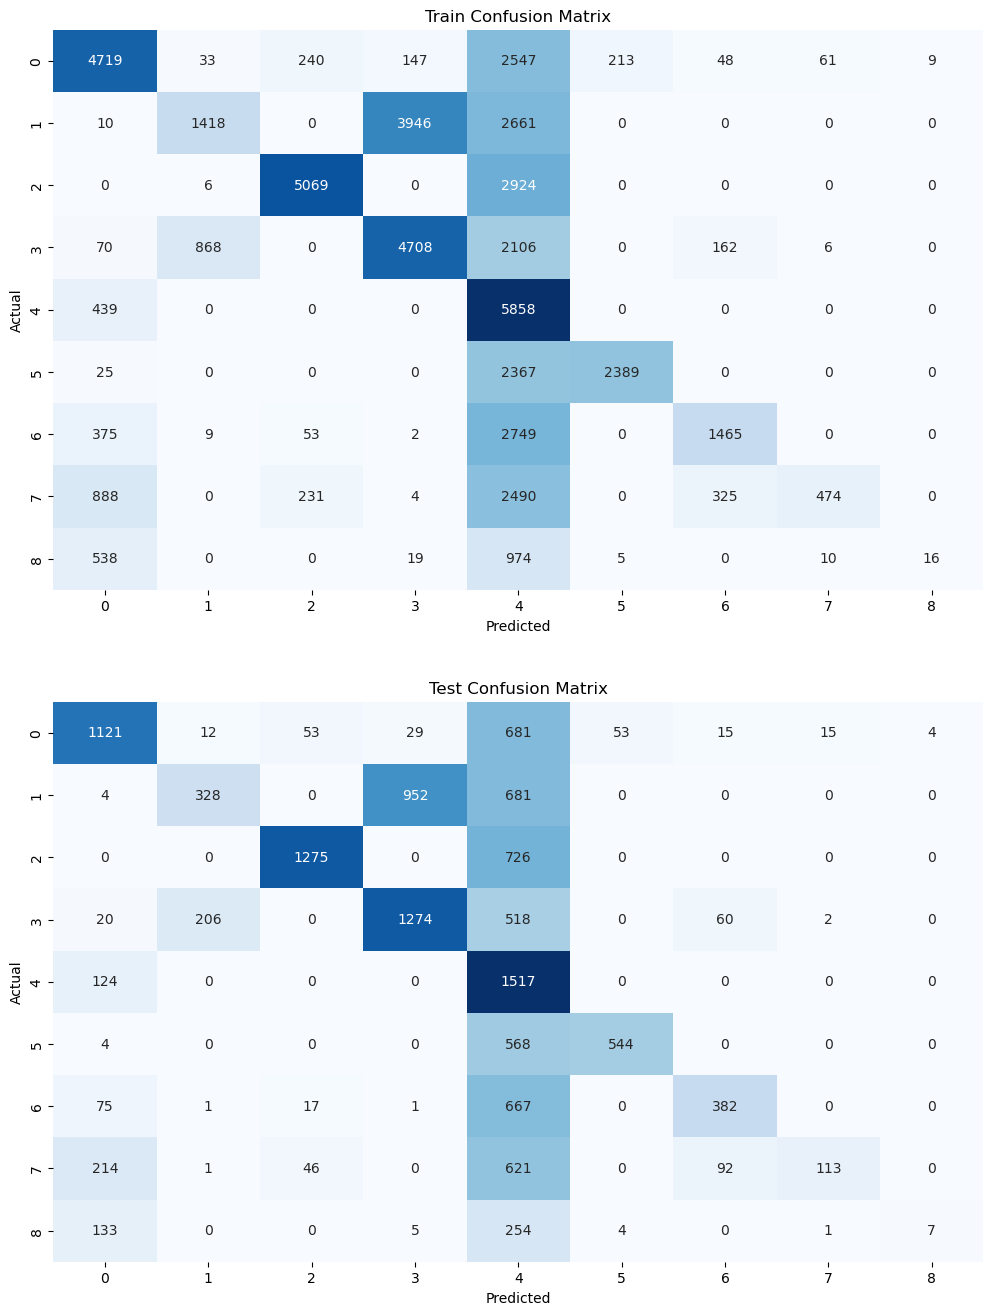

CPU times: total: 8min 42s
Wall time: 1min 7s


In [27]:
%%time
# LogisticRegression
warnings.filterwarnings('ignore')
logcls=clasicalmodels(LogisticRegression(max_iter=5000,random_state=86),model_name='LGR')

KNeighborsClassifier(n_neighbors=6) :
Train Accuracy : 0.7725
Test  Accuracy : 0.7666
Train Precision: 0.8730
Test  Precision: 0.8640
Train Recall   : 0.7725
Test  Recall   : 0.7666
Train F1 Score : 0.7810
Test  F1 Score : 0.7735


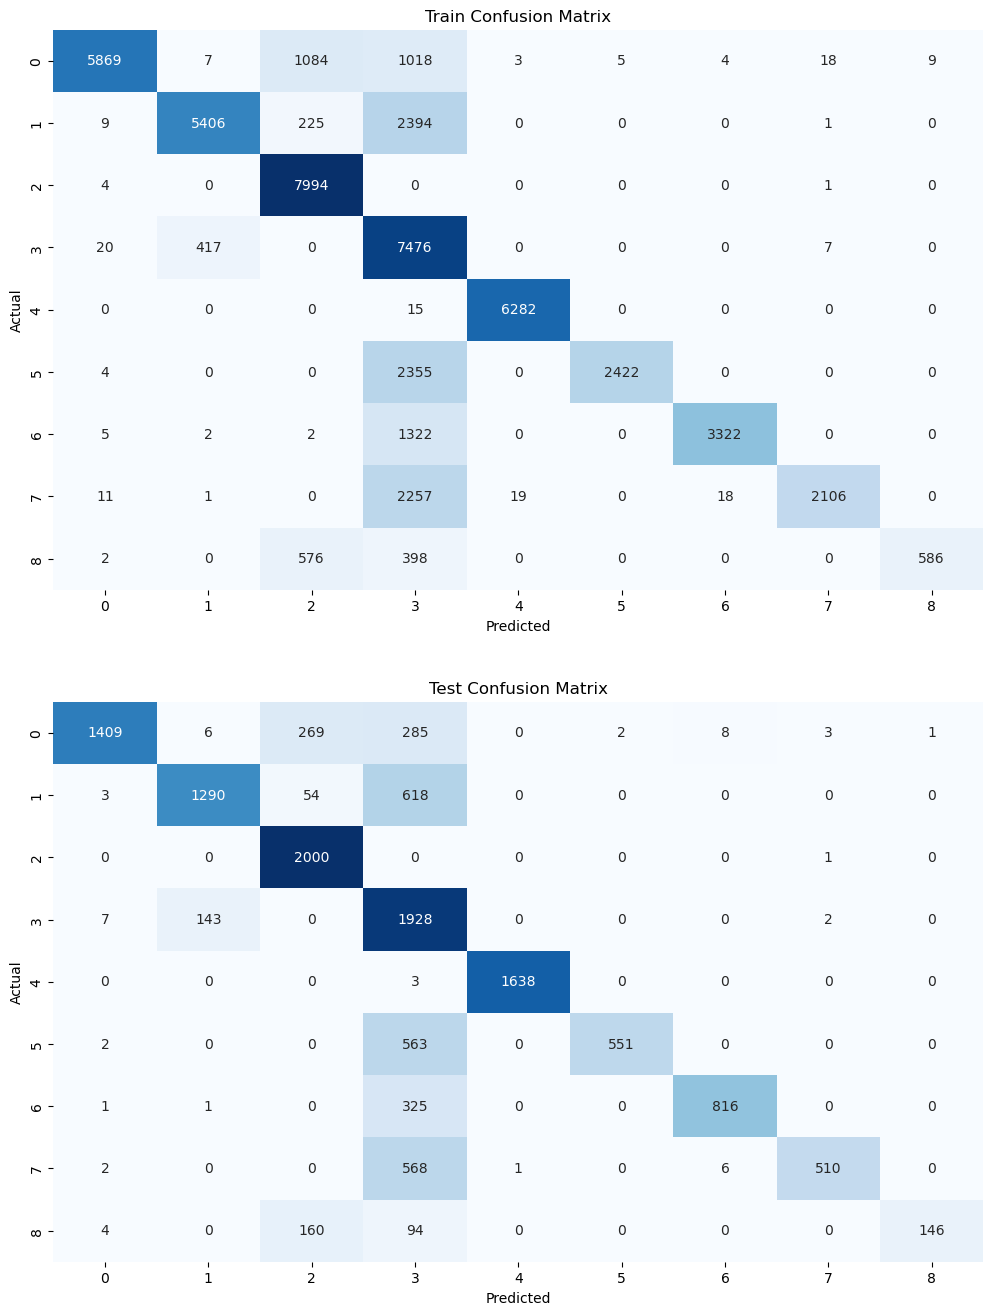

CPU times: total: 5.92 s
Wall time: 5.93 s


In [28]:
%%time
# KNeighborsClassifier
warnings.filterwarnings('ignore')
knc=clasicalmodels(KNeighborsClassifier(n_neighbors=6),model_name='KNC')
warnings.filterwarnings('ignore')

SVC(C=100, gamma=100, random_state=42) :
Train Accuracy : 0.7904
Test  Accuracy : 0.6750
Train Precision: 0.9109
Test  Precision: 0.8347
Train Recall   : 0.7904
Test  Recall   : 0.6750
Train F1 Score : 0.8113
Test  F1 Score : 0.6791


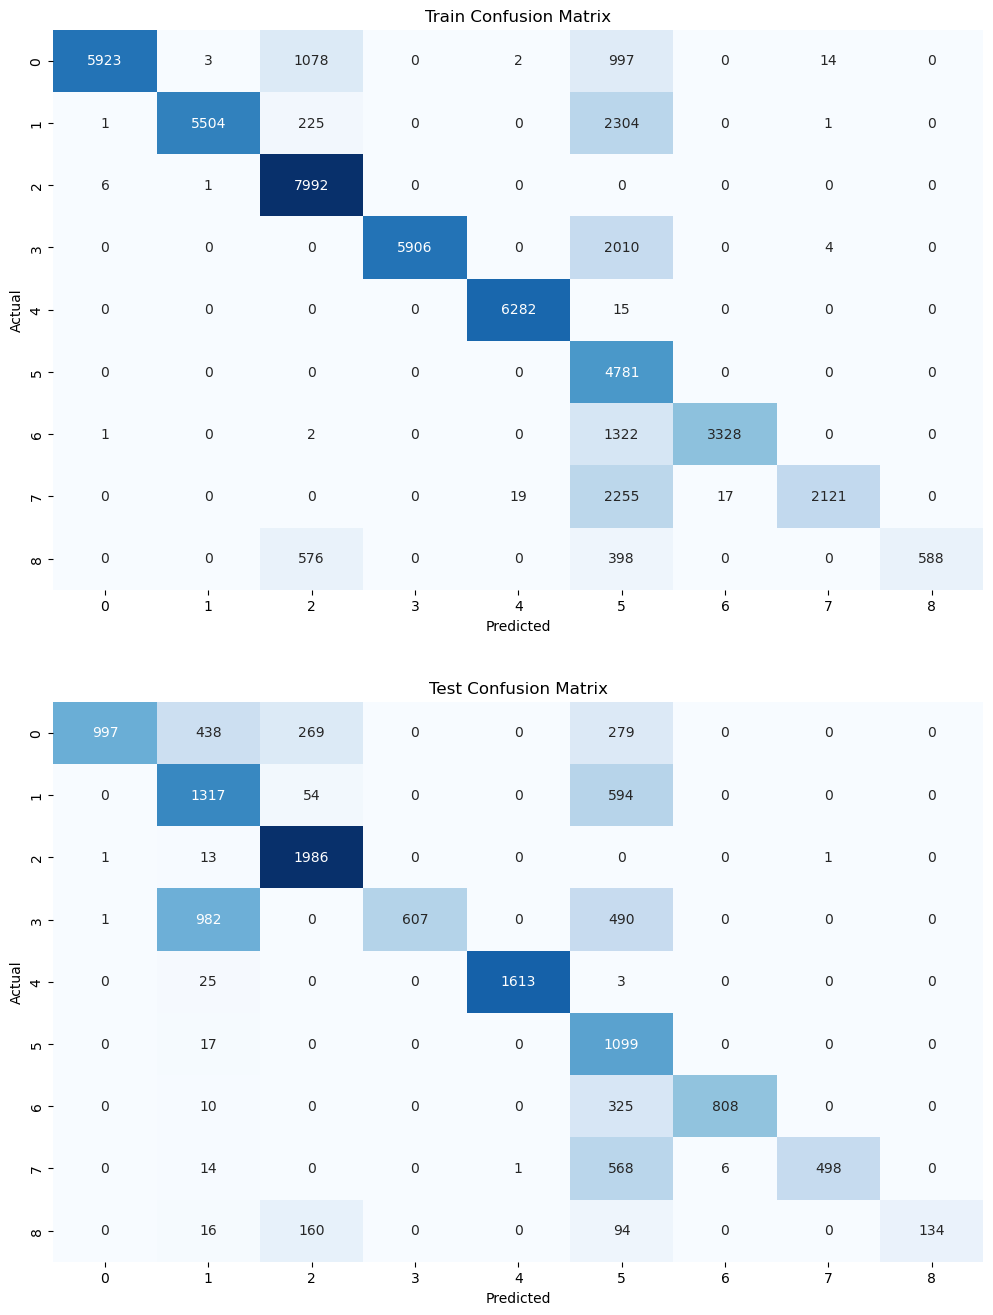

CPU times: total: 7min 49s
Wall time: 7min 52s


In [29]:
%%time
# SVC
warnings.filterwarnings('ignore')
svc=clasicalmodels(SVC(C = 100 ,random_state=42, gamma = 100),model_name='SVC')

GaussianNB() :
Train Accuracy : 0.5203
Test  Accuracy : 0.5221
Train Precision: 0.6119
Test  Precision: 0.6080
Train Recall   : 0.5203
Test  Recall   : 0.5221
Train F1 Score : 0.4983
Test  F1 Score : 0.5002


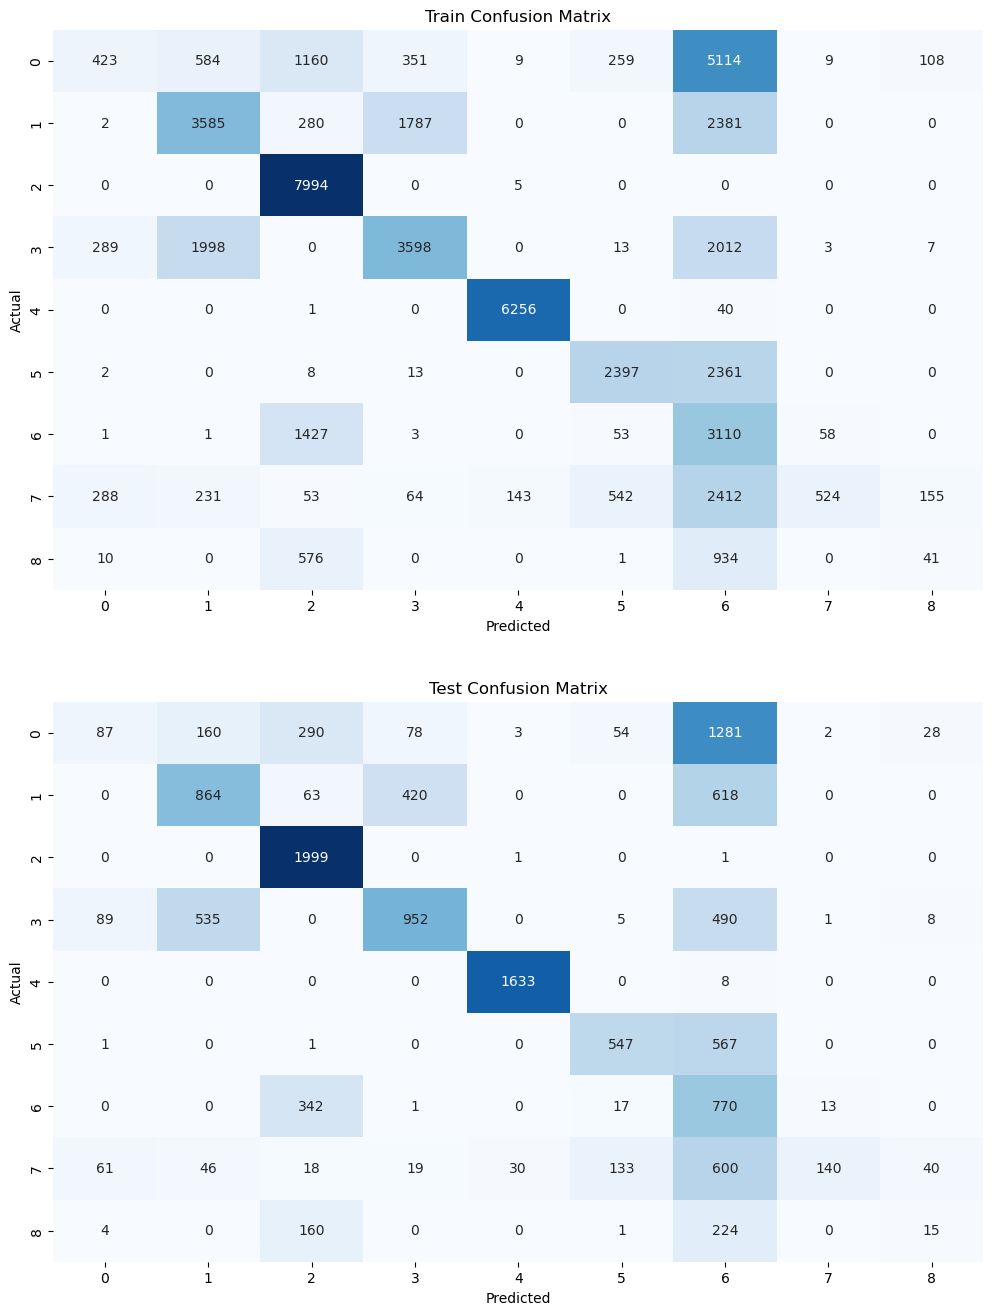

CPU times: total: 641 ms
Wall time: 646 ms


In [30]:
%%time
# GaussianNB
warnings.filterwarnings('ignore')
gauss=clasicalmodels(GaussianNB(),model_name='GNB')

In [31]:
def clasicalmodels(model,pathname,model_name,xtrain=xtrain,ytrain=ytrain,xtest=xtest,ytest=ytest):
    model.fit(xtrain, ytrain)
    ypred_train = model.predict(xtrain)
    ypred_test = model.predict(xtest)
    print(model,':')
    
    tr_acc = accuracy_score(ytrain, ypred_train)
    te_acc = accuracy_score(ytest, ypred_test)
    tr_p = precision_score(ytrain, ypred_train, average="weighted")
    te_p = precision_score(ytest, ypred_test, average="weighted")
    tr_r = recall_score(ytrain, ypred_train, average="weighted")
    te_r = recall_score(ytest, ypred_test, average="weighted")
    tr_f = f1_score(ytrain, ypred_train, average="weighted")
    te_f = f1_score(ytest, ypred_test, average="weighted")
    
    print(f"Train Acc uracy : {tr_acc:.4f}")
    print(f"Test  Accuracy : {te_acc:.4f}")
    print(f"Train Precision: {tr_p:.4f}")
    print(f"Test  Precision: {te_p:.4f}")
    print(f"Train Recall   : {tr_r:.4f}")
    print(f"Test  Recall   : {te_r:.4f}")    
    print(f"Train F1 Score : {tr_f:.4f}")
    print(f"Test  F1 Score : {te_f:.4f}")

    model_results.loc[len(model_results)] = [model_name,tr_acc,te_acc,tr_p, te_p, tr_r, te_r, tr_f, te_f]


    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    sns.heatmap(confusion_matrix(ytrain, ypred_train),annot=True, fmt='d', ax=axes[0], cmap="Blues", cbar=False)
    axes[0].set_title("Train Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    
    sns.heatmap(confusion_matrix(ytest, ypred_test),annot=True, fmt='d', ax=axes[1], cmap="Blues", cbar=False)
    axes[1].set_title("Test Confusion Matrix")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    plt.show()
        
    from pathlib import Path
    root=Path("models")
    root.mkdir(exist_ok=True)
    path = root / f"{str(pathname)}.pkl"
    joblib.dump(model, path)

    return model
        

GradientBoostingClassifier(max_depth=6, random_state=42) :
Train Acc uracy : 0.7903
Test  Accuracy : 0.7848
Train Precision: 0.9108
Test  Precision: 0.9091
Train Recall   : 0.7903
Test  Recall   : 0.7848
Train F1 Score : 0.8112
Test  F1 Score : 0.8067


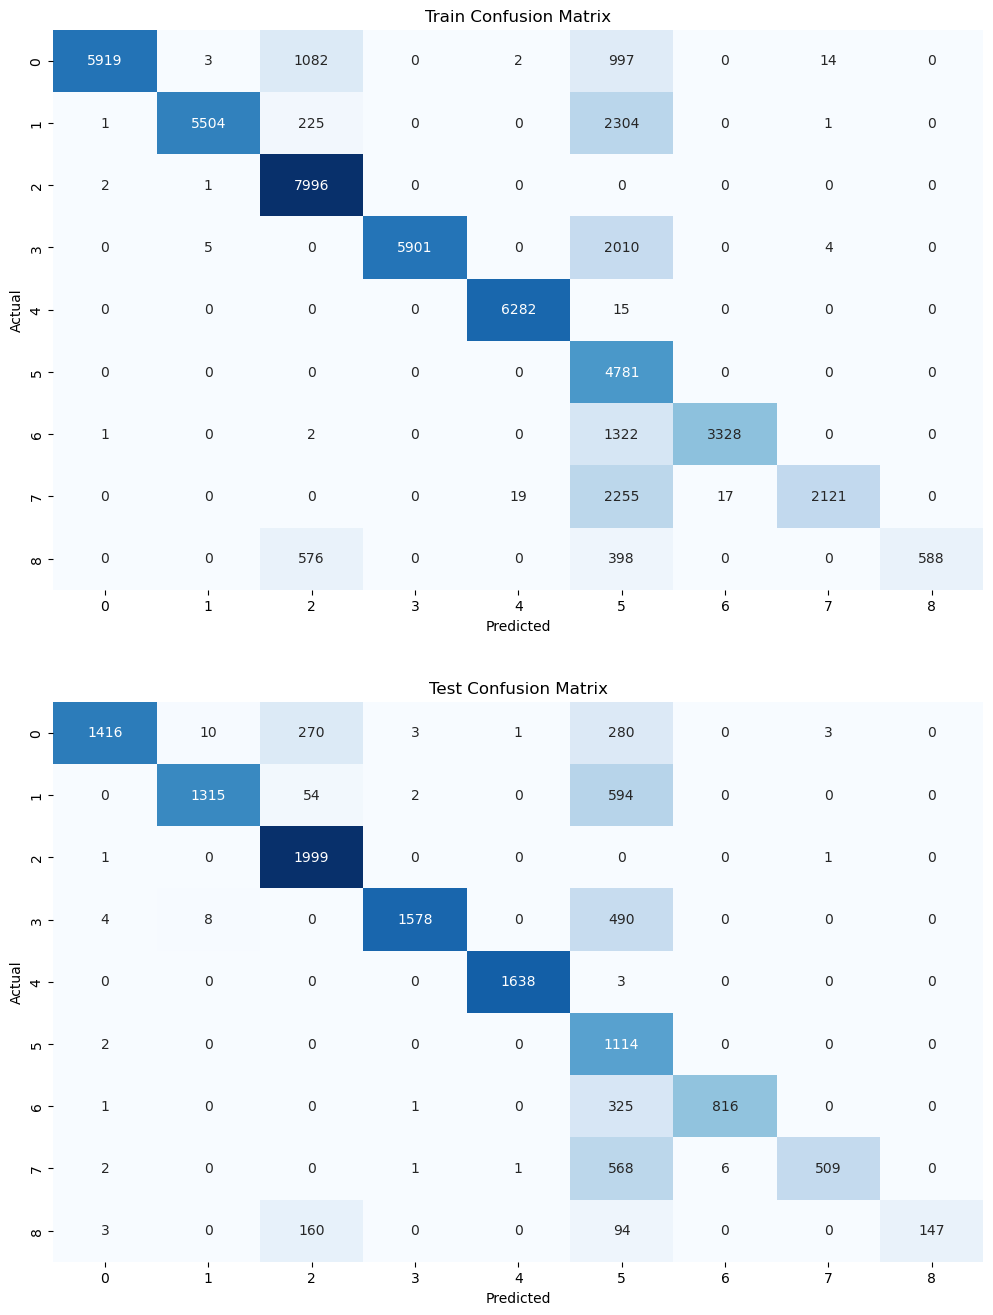

CPU times: total: 47.1 s
Wall time: 47.4 s


In [32]:
%%time
# GradientBoostingClassifier
warnings.filterwarnings('ignore')
gradc=clasicalmodels(GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=6,random_state=42)
,'GradientBoostingClassifier',model_name='GBC')

AdaBoostClassifier(learning_rate=0.5, n_estimators=25, random_state=42) :
Train Acc uracy : 0.2686
Test  Accuracy : 0.2656
Train Precision: 0.1842
Test  Precision: 0.1894
Train Recall   : 0.2686
Test  Recall   : 0.2656
Train F1 Score : 0.1608
Test  F1 Score : 0.1595


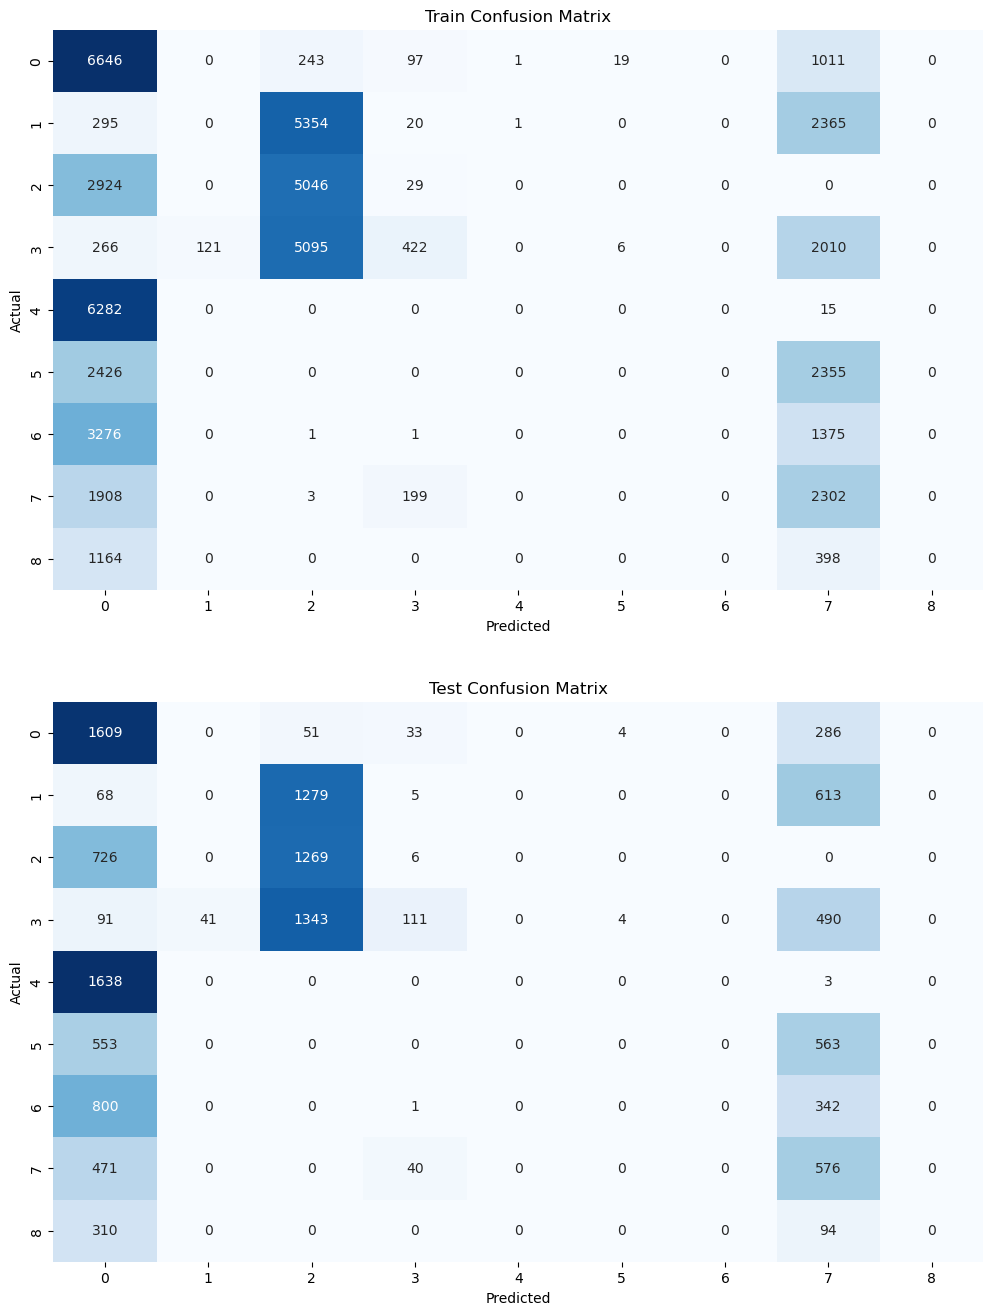

CPU times: total: 1.02 s
Wall time: 1.03 s


In [33]:
%%time
# AdaBoostClassifier
warnings.filterwarnings('ignore')
adaboost=clasicalmodels(AdaBoostClassifier(n_estimators=25,learning_rate=0.5,random_state=42),'AdaBoostClassifier',model_name='ABC')

LinearDiscriminantAnalysis() :
Train Acc uracy : 0.3725
Test  Accuracy : 0.3731
Train Precision: 0.4066
Test  Precision: 0.4125
Train Recall   : 0.3725
Test  Recall   : 0.3731
Train F1 Score : 0.3261
Test  F1 Score : 0.3273


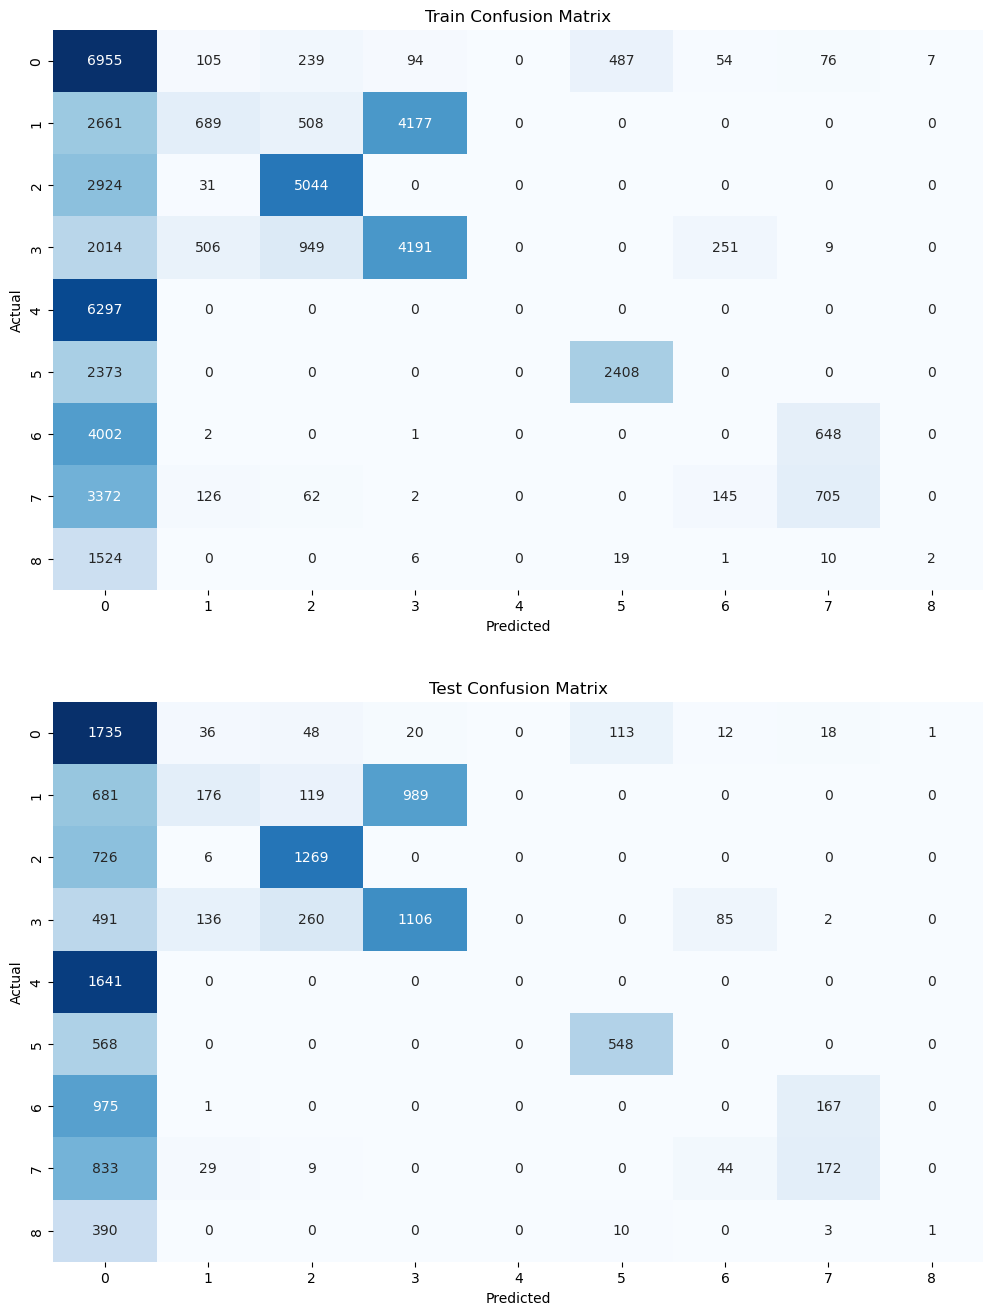

CPU times: total: 2 s
Wall time: 511 ms


In [34]:
%%time
# LinearDiscriminantAnalysis
warnings.filterwarnings('ignore')
bag_gauss=clasicalmodels(LinearDiscriminantAnalysis(),'LinearDiscriminantAnalysis',model_name='LDA')

In [35]:
model_results

,Model,Train_Acc,Test_Acc,Train_Prec,Test_Prec,Train_Rec,Test_Rec,Train_F1,Test_F1
0,DTC,0.687905,0.686736,0.773374,0.772282,0.687905,0.686736,0.678380,0.677484
1,RFC,0.790092,0.777645,0.910540,0.898959,0.790092,0.777645,0.810919,0.798405
2,LGR,0.486549,0.488897,0.666798,0.662693,0.486549,0.488897,0.484980,0.485678
3,KNC,0.772468,0.766617,0.873003,0.863989,0.772468,0.766617,0.780982,0.773476
4,SVC,0.790390,0.675037,0.910906,0.834655,0.790390,0.675037,0.811272,0.679126
5,GNB,0.520307,0.522131,0.611854,0.607981,0.520307,0.522131,0.498312,0.500239
6,GBC,0.790297,0.784799,0.910834,0.909080,0.790297,0.784799,0.811160,0.806672
7,ABC,0.268574,0.265648,0.184250,0.189444,0.268574,0.265648,0.160771,0.159456
8,LDA,0.372494,0.373100,0.406631,0.412478,0.372494,0.373100,0.326111,0.327319


In [36]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [37]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [38]:
class FFN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(4, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),

            nn.Linear(1024, 2048),
            nn.BatchNorm1d(2048),
            nn.LeakyReLU(),

            nn.Linear(2048, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(),

            nn.Linear(256, 128),
            nn.LeakyReLU(),

            nn.Linear(128, 64),
            nn.LeakyReLU(),

            nn.Linear(64, 9)
        )

    def forward(self, x):
        return self.net(x)

In [39]:
FNN_model = FFN()
FNN_model.to(device)

FFN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.01)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.01)
    (9): Linear(in_features=1024, out_features=2048, bias=True)
    (10): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.01)
    (12): Linear(in_features=2048, out_features=1024, bias=True)
    (13): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): LeakyReLU(negative_slope=0.01)
   

In [40]:
class CustomDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X.values, dtype=torch.float32)
        self.y = torch.tensor(y.values.squeeze(), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [41]:
train_dataset = CustomDataset(xtrain,ytrain)

In [42]:
test_dataset = CustomDataset(xtest,ytest)

In [43]:
train_dataloader = DataLoader(train_dataset, batch_size=30000, shuffle=True)

In [44]:
test_dataloader = DataLoader(test_dataset, batch_size=30000, shuffle=True)

In [45]:
def accuracy_fn(y_true, y_pred):
    return (y_true == y_pred).sum().item() / len(y_true)

In [46]:
def train(model, epochs, train_dataloader=train_dataloader, device=device):
    torch.cuda.manual_seed_all(33)

    for epoch in range(epochs):
        model.train()
        avg_loss = 0.0
        avg_acc  = 0.0

        for step, (x, y) in enumerate(train_dataloader):
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            logits = model(x)  # shape: [B, 10]
            loss = loss_fn(logits, y)      # y: [B] with 0/1

            loss.backward()
            optimizer.step()

            preds = logits.argmax(dim=1)   # NO softmax
            acc = accuracy_fn(y, preds)

            avg_loss += loss.item()
            avg_acc  += acc

        avg_loss /= (step + 1)
        avg_acc  /= (step + 1)

        print(f"Epoch {epoch} | Avg Loss {avg_loss:.4f} | Avg Acc {avg_acc:.4f}")


In [47]:
loss_fn = nn.CrossEntropyLoss()  
optimizer = torch.optim.Adam(FNN_model.parameters(), lr=0.001)

In [48]:
train(model=FNN_model,epochs=100)

Epoch 0 | Avg Loss 2.1605 | Avg Acc 0.1866
Epoch 1 | Avg Loss 1.9965 | Avg Acc 0.4328
Epoch 2 | Avg Loss 1.8402 | Avg Acc 0.4419
Epoch 3 | Avg Loss 1.7043 | Avg Acc 0.4529
Epoch 4 | Avg Loss 1.5762 | Avg Acc 0.4641
Epoch 5 | Avg Loss 1.4610 | Avg Acc 0.4703
Epoch 6 | Avg Loss 1.3707 | Avg Acc 0.4970
Epoch 7 | Avg Loss 1.2874 | Avg Acc 0.5555
Epoch 8 | Avg Loss 1.2034 | Avg Acc 0.6009
Epoch 9 | Avg Loss 1.1263 | Avg Acc 0.6120
Epoch 10 | Avg Loss 1.0716 | Avg Acc 0.6144
Epoch 11 | Avg Loss 1.0009 | Avg Acc 0.6228
Epoch 12 | Avg Loss 0.9580 | Avg Acc 0.6327
Epoch 13 | Avg Loss 0.9755 | Avg Acc 0.6197
Epoch 14 | Avg Loss 0.9491 | Avg Acc 0.6468
Epoch 15 | Avg Loss 0.9031 | Avg Acc 0.6696
Epoch 16 | Avg Loss 0.8654 | Avg Acc 0.6733
Epoch 17 | Avg Loss 0.8383 | Avg Acc 0.6753
Epoch 18 | Avg Loss 0.8099 | Avg Acc 0.6807
Epoch 19 | Avg Loss 0.7910 | Avg Acc 0.6827
Epoch 20 | Avg Loss 0.7720 | Avg Acc 0.6932
Epoch 21 | Avg Loss 0.7614 | Avg Acc 0.6953
Epoch 22 | Avg Loss 0.7507 | Avg Acc 0.692

In [49]:
xtrain = torch.tensor(xtrain.values, dtype=torch.float32)
xtest  = torch.tensor(xtest.values,  dtype=torch.float32)
ytrain = torch.tensor(ytrain.values, dtype=torch.long)
ytest  = torch.tensor(ytest.values,  dtype=torch.long)

In [50]:
xtrain = xtrain.to(device)
ytrain = ytrain.to(device)
xtest = xtest.to(device)
ytest = ytest.to(device)


In [51]:
def evaluate_model(model, loader, device):
    model.eval()

    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x).argmax(1)

            y_true.extend(y.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    return {
        "acc": (y_true == y_pred).mean(),
        "precision": precision_score(y_true, y_pred, average="weighted"),
        "recall": recall_score(y_true, y_pred, average="weighted"),
        "f1": f1_score(y_true, y_pred, average="weighted"),
        "cm": confusion_matrix(y_true, y_pred)
    }

In [52]:
def plot_cm_and_store(model, train_loader, test_loader, device, model_results, name="FFN"):
    tr = evaluate_model(model, train_loader, device)
    te = evaluate_model(model, test_loader, device)

    print("Train Accuracy :", tr["acc"])
    print("Test  Accuracy :", te["acc"])
    print("Train Precision:", tr["precision"])
    print("Test  Precision:", te["precision"])
    print("Train Recall   :", tr["recall"])
    print("Test  Recall   :", te["recall"])
    print("Train F1-score :", tr["f1"])
    print("Test  F1-score :", te["f1"])

    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.heatmap(tr["cm"], annot=True, fmt="d", ax=ax[0], cbar=False)
    ax[0].set_title(f"Train Acc = {tr['acc']:.3f}")
    sns.heatmap(te["cm"], annot=True, fmt="d", ax=ax[1], cbar=False)
    ax[1].set_title(f"Test Acc = {te['acc']:.3f}")
    plt.tight_layout(); plt.show()

    model_results.loc[len(model_results)] = [
        name,
        tr["acc"], te["acc"],
        tr["precision"], te["precision"],
        tr["recall"], te["recall"],
        tr["f1"], te["f1"]
    ]


Train Accuracy : 0.6487815783590432
Test  Accuracy : 0.6488822652757079
Train Precision: 0.8171879933819299
Test  Precision: 0.8165436329063968
Train Recall   : 0.6487815783590432
Test  Recall   : 0.6488822652757079
Train F1-score : 0.6708720247876633
Test  F1-score : 0.6702422311927532


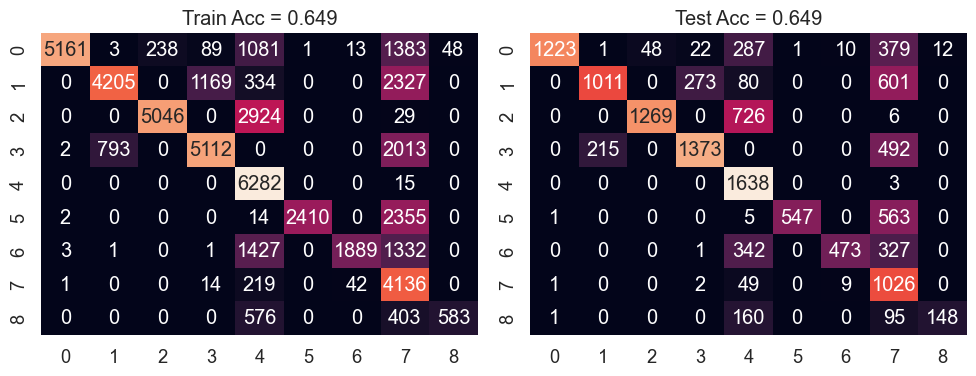

In [69]:
plot_cm_and_store(FNN_model, train_dataloader, test_dataloader, device,model_results)

In [70]:
model_results

,Model,Train_Acc,Test_Acc,Train_Prec,Test_Prec,Train_Rec,Test_Rec,Train_F1,Test_F1
0,DTC,0.687905,0.686736,0.773374,0.772282,0.687905,0.686736,0.678380,0.677484
1,RFC,0.790092,0.777645,0.910540,0.898959,0.790092,0.777645,0.810919,0.798405
2,LGR,0.486549,0.488897,0.666798,0.662693,0.486549,0.488897,0.484980,0.485678
3,KNC,0.772468,0.766617,0.873003,0.863989,0.772468,0.766617,0.780982,0.773476
4,SVC,0.790390,0.675037,0.910906,0.834655,0.790390,0.675037,0.811272,0.679126
5,GNB,0.520307,0.522131,0.611854,0.607981,0.520307,0.522131,0.498312,0.500239
6,GBC,0.790297,0.784799,0.910834,0.909080,0.790297,0.784799,0.811160,0.806672
7,ABC,0.268574,0.265648,0.184250,0.189444,0.268574,0.265648,0.160771,0.159456
8,LDA,0.372494,0.373100,0.406631,0.412478,0.372494,0.373100,0.326111,0.327319
9,FFN,0.648782,0.648882,0.817188,0.816544,0.648782,0.648882,0.670872,0.670242


In [71]:
def plot_model_metrics1(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = ["#88ccee", "#44aa99"]  # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]  # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach


    # 1-4
    for i, m in enumerate(metrics):
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]], ax=axes[i])
        axes[i].set_title(f'{m} - Train vs Test', fontsize=16)
        axes[i].set_ylim(0, 1.05)
        axes[i].tick_params(axis='x', rotation=30)

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary, ax=axes[4])
    axes[4].set_title('Train Summary (Max / Min / Avg)', fontsize=16)
    axes[4].set_ylim(0, 1.05)
    for container in axes[4].containers:  # annotate only summary
        axes[4].bar_label(container, fmt="%.3f", padding=3)

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary, ax=axes[5])
    axes[5].set_title('Test Summary (Max / Min / Avg)', fontsize=16)
    axes[5].set_ylim(0, 1.05)
    for container in axes[5].containers:  # annotate only summary
        axes[5].bar_label(container, fmt="%.3f", padding=3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics1.jpg", dpi=9000, bbox_inches="tight")
    plt.show()


In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics2(df):
    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    palette_train = ["#88ccee", "#44aa99"]      # soft cyan / turquoise
    palette_test  = ["#ddcc77", "#cc6677"]      # soft mustard / rose
    palette_summary = ["#fb9a99", "#e31a1c", "#fdbf6f"]  # pink / red / peach

    # 1-4
    for m in metrics:
        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        plt.figure(figsize=(16, 8))
        sns.barplot(x='Model', y='Score', hue='Dataset', data=df_long,
                    palette=[palette_train[0], palette_test[0]])
        plt.title(f'{m} - Train vs Test', fontsize=18)
        plt.ylim(0, 1.05)
        plt.xticks(rotation=30)
        plt.tight_layout()
        plt.show()

    # 5
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })
    summary_train = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                    var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_train,
                palette=palette_summary)
    plt.title('Train Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()

    # 6
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })
    summary_test = pd.DataFrame(summary_list).melt(id_vars='Metric',
                                                   var_name='Stat', value_name='Score')

    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Stat', data=summary_test,
                palette=palette_summary)
    plt.title('Test Summary (Max / Min / Avg)', fontsize=18)
    plt.ylim(0, 1.05)
    for container in plt.gca().containers:
        plt.gca().bar_label(container, fmt="%.3f", padding=3)
    plt.tight_layout()
    plt.show()


In [ ]:
plot_model_metrics2(model_results)

In [ ]:
def plot_model_metrics1(df):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2, 3, figsize=(32, 20))
    axes = axes.flatten()

    palette_train = "#4DBBD5"
    palette_test  = "#E64B35"

    palette_summary = {
        "Max": "#3C5488",
        "Min": "#00A087",
        "Avg": "#F39B7F"
    }

    # -------- 1–4 METRIC PLOTS --------
    for i, m in enumerate(metrics):

        df_long = df[['Model', f'Train_{m}', f'Test_{m}']].copy()
        df_long = df_long.melt('Model', var_name='Dataset', value_name='Score')
        df_long['Dataset'] = df_long['Dataset'].apply(lambda x: 'Train' if 'Train' in x else 'Test')

        ax = axes[i]

        models = df_long['Model'].unique()
        x = np.arange(len(models))

        train_vals = df_long[df_long.Dataset=='Train']['Score'].values
        test_vals = df_long[df_long.Dataset=='Test']['Score'].values

        # lollipop stems
        ax.vlines(x-0.15, 0, train_vals, color=palette_train, lw=4, alpha=0.4)
        ax.vlines(x+0.15, 0, test_vals, color=palette_test, lw=4, alpha=0.4)

        # scatter heads
        ax.scatter(x-0.15, train_vals, s=250, color=palette_train, edgecolor='black', zorder=3, label="Train")
        ax.scatter(x+0.15, test_vals, s=250, color=palette_test, edgecolor='black', zorder=3, label="Test")

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=30)

        ax.set_ylim(0,1.05)
        ax.set_title(f'{m} - Train vs Test', fontsize=18)

        ax.grid(True, linestyle='--', alpha=0.3)
        ax.legend()

    # -------- TRAIN SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_train[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Train Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)


    # -------- TEST SUMMARY --------
    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    x = np.arange(len(metrics))

    for stat in ['Max','Min','Avg']:
        vals = summary_test[stat].values
        ax.plot(x, vals, marker='o', markersize=12,
                linewidth=4,
                label=stat,
                color=palette_summary[stat])

        for i_val, v in enumerate(vals):
            ax.text(i_val, v+0.015, f"{v:.3f}", ha='center', fontsize=11)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylim(0,1.05)
    ax.set_title('Test Summary (Max / Min / Avg)', fontsize=18)
    ax.legend()

    ax.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig("plot_model_metrics3.jpg", dpi=1000, bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc', 'Prec', 'Rec', 'F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig = plt.figure(figsize=(32,20))
    axes = [plt.subplot(2,3,i+1, projection='polar') if i<4 else plt.subplot(2,3,i+1) for i in range(6)]

    train_color = "#00c2ff"
    test_color = "#ff5e78"

    glow_train = "#a6ecff"
    glow_test = "#ffc1cc"

    # -------------------------
    # 1–4 RADIAL MODEL PLOTS
    # -------------------------

    for i, m in enumerate(metrics):

        ax = axes[i]

        train_vals = df[f'Train_{m}'].values
        test_vals = df[f'Test_{m}'].values

        models = df['Model'].values
        angles = np.linspace(0,2*np.pi,len(models),endpoint=False)

        train_vals = np.append(train_vals,train_vals[0])
        test_vals = np.append(test_vals,test_vals[0])
        angles = np.append(angles,angles[0])

        # glow layer
        ax.plot(angles,train_vals,color=glow_train,linewidth=12,alpha=0.25)
        ax.plot(angles,test_vals,color=glow_test,linewidth=12,alpha=0.25)

        # main layer
        ax.plot(angles,train_vals,color=train_color,linewidth=3,label="Train")
        ax.plot(angles,test_vals,color=test_color,linewidth=3,label="Test")

        ax.scatter(angles,train_vals,s=180,color=train_color,edgecolor="black",zorder=3)
        ax.scatter(angles,test_vals,s=180,color=test_color,edgecolor="black",zorder=3)

        ax.set_ylim(0,1.05)
        ax.set_title(f"{m} Comparison",fontsize=18,pad=20)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(models,fontsize=11)

        ax.legend(loc="upper right")

    # -------------------------
    # TRAIN SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Train_{m}'].max(),
            'Min': df[f'Train_{m}'].min(),
            'Avg': df[f'Train_{m}'].mean()
        })

    summary_train = pd.DataFrame(summary_list)

    ax = axes[4]

    sizes = [
        summary_train['Max'].mean(),
        summary_train['Min'].mean(),
        summary_train['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Train Summary (Max / Min / Avg)",fontsize=18)


    # -------------------------
    # TEST SUMMARY DONUT
    # -------------------------

    summary_list = []
    for m in metrics:
        summary_list.append({
            'Metric': m,
            'Max': df[f'Test_{m}'].max(),
            'Min': df[f'Test_{m}'].min(),
            'Avg': df[f'Test_{m}'].mean()
        })

    summary_test = pd.DataFrame(summary_list)

    ax = axes[5]

    sizes = [
        summary_test['Max'].mean(),
        summary_test['Min'].mean(),
        summary_test['Avg'].mean()
    ]

    labels = ["Max","Min","Avg"]

    colors = ["#ff6b6b","#4ecdc4","#ffe66d"]

    wedges,texts,autotexts = ax.pie(
        sizes,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=colors,
        pctdistance=0.8,
        wedgeprops=dict(width=0.45)
    )

    ax.set_title("Test Summary (Max / Min / Avg)",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics2.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']
    sns.set(style="whitegrid", font_scale=1.2)

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    models = df['Model'].values
    x = np.arange(len(models))

    # ------------------------------------------------
    # 1 RADAR CHART (Average metric comparison)
    # ------------------------------------------------

    ax1.remove()
    ax1 = fig.add_subplot(2,3,1, projection='polar')

    train_avg = [df[f'Train_{m}'].mean() for m in metrics]
    test_avg  = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    train_avg += train_avg[:1]
    test_avg += test_avg[:1]
    angles = np.append(angles,angles[0])

    ax1.plot(angles,train_avg,linewidth=3,label="Train",color="#00c2ff")
    ax1.fill(angles,train_avg,alpha=0.25,color="#00c2ff")

    ax1.plot(angles,test_avg,linewidth=3,label="Test",color="#ff6b6b")
    ax1.fill(angles,test_avg,alpha=0.25,color="#ff6b6b")

    ax1.set_xticks(angles[:-1])
    ax1.set_xticklabels(metrics)
    ax1.set_ylim(0,1)
    ax1.set_title("Metric Radar Comparison",fontsize=18)
    ax1.legend()


    # ------------------------------------------------
    # 2 BUBBLE SCATTER
    # ------------------------------------------------

    train_acc = df['Train_Acc']
    test_acc = df['Test_Acc']

    sizes = (train_acc + test_acc)*800

    ax2.scatter(train_acc,test_acc,
                s=sizes,
                c=train_acc,
                cmap="viridis",
                alpha=0.7,
                edgecolors="black")

    for i,m in enumerate(models):
        ax2.text(train_acc[i],test_acc[i],m,ha='center',va='center')

    ax2.set_xlabel("Train Accuracy")
    ax2.set_ylabel("Test Accuracy")
    ax2.set_title("Train vs Test Accuracy Bubble Plot",fontsize=18)


    # ------------------------------------------------
    # 3 HEATMAP
    # ------------------------------------------------

    heat_df = df.set_index("Model")[
        [f'Train_{m}' for m in metrics] +
        [f'Test_{m}' for m in metrics]
    ]

    sns.heatmap(
        heat_df,
        cmap="coolwarm",
        annot=True,
        fmt=".3f",
        linewidths=0.5,
        ax=ax3
    )

    ax3.set_title("Model Performance Heatmap",fontsize=18)


    # ------------------------------------------------
    # 4 LOLLIPOP PLOT
    # ------------------------------------------------

    metric = "F1"

    train_vals = df[f'Train_{metric}']
    test_vals = df[f'Test_{metric}']

    ax4.vlines(x-0.1,0,train_vals,color="#00c2ff",lw=5,alpha=0.6)
    ax4.vlines(x+0.1,0,test_vals,color="#ff6b6b",lw=5,alpha=0.6)

    ax4.scatter(x-0.1,train_vals,s=200,color="#00c2ff",edgecolor="black",label="Train")
    ax4.scatter(x+0.1,test_vals,s=200,color="#ff6b6b",edgecolor="black",label="Test")

    ax4.set_xticks(x)
    ax4.set_xticklabels(models,rotation=30)
    ax4.set_ylim(0,1.05)

    ax4.set_title("F1 Score Comparison",fontsize=18)
    ax4.legend()


    # ------------------------------------------------
    # 5 DONUT CHART (TRAIN SUMMARY)
    # ------------------------------------------------

    train_stats = [
        max(df['Train_Acc']),
        min(df['Train_Acc']),
        df['Train_Acc'].mean()
    ]

    labels = ["Max","Min","Avg"]

    wedges,_,_ = ax5.pie(
        train_stats,
        labels=labels,
        autopct='%0.3f',
        startangle=90,
        colors=["#ff6b6b","#4ecdc4","#ffe66d"],
        wedgeprops=dict(width=0.45)
    )

    ax5.set_title("Train Accuracy Summary",fontsize=18)


    # ------------------------------------------------
    # 6 RADIAL BAR CHART (TEST SUMMARY)
    # ------------------------------------------------

    ax6.remove()
    ax6 = fig.add_subplot(2,3,6, projection='polar')

    test_avg = [df[f'Test_{m}'].mean() for m in metrics]

    angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False)

    bars = ax6.bar(
        angles,
        test_avg,
        width=0.4,
        color=plt.cm.plasma(test_avg),
        alpha=0.85
    )

    ax6.set_xticks(angles)
    ax6.set_xticklabels(metrics)

    ax6.set_ylim(0,1)

    ax6.set_title("Average Test Metrics Radial Bars",fontsize=18)

    plt.tight_layout()
    plt.savefig("plot_model_metrics4.jpg", dpi=1000, bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    # ------------------------------------------------
    # 1 Accuracy Train vs Test
    # ------------------------------------------------

    df_acc = df[['Model','Train_Acc','Test_Acc']].melt(
        id_vars="Model",
        var_name="Dataset",
        value_name="Score"
    )

    sns.barplot(
        data=df_acc,
        x="Model",
        y="Score",
        hue="Dataset",
        palette=["#4DBBD5","#E64B35"],
        ax=ax1
    )

    ax1.set_title("Accuracy: Train vs Test",fontsize=18)
    ax1.set_ylim(0,1.05)
    ax1.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 2 Precision Recall F1 Trend
    # ------------------------------------------------

    for m,color in zip(['Prec','Rec','F1'],["#00A087","#3C5488","#F39B7F"]):

        ax2.plot(
            df["Model"],
            df[f"Test_{m}"],
            marker="o",
            linewidth=3,
            label=m,
            color=color
        )

    ax2.set_ylim(0,1.05)
    ax2.set_title("Test Metric Trends Across Models",fontsize=18)
    ax2.tick_params(axis='x',rotation=30)
    ax2.legend()

    # ------------------------------------------------
    # 3 Overfitting Gap
    # ------------------------------------------------

    gap = df['Train_Acc'] - df['Test_Acc']

    colors = ["#2ECC71" if g<0.02 else "#E74C3C" for g in gap]

    ax3.bar(df["Model"],gap,color=colors)

    ax3.axhline(0,color="black",linewidth=1)

    ax3.set_title("Train-Test Accuracy Gap (Overfitting Indicator)",fontsize=18)
    ax3.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 4 Metric Distribution
    # ------------------------------------------------

    dist_df = df[[f'Train_{m}' for m in metrics]].copy()

    dist_df.columns = metrics

    sns.boxplot(
        data=dist_df,
        palette="Set2",
        ax=ax4
    )

    ax4.set_ylim(0,1.05)
    ax4.set_title("Distribution of Train Metrics",fontsize=18)

    # ------------------------------------------------
    # 5 Train Summary
    # ------------------------------------------------

    train_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Train_{m}"].max() for m in metrics],
        "Min":[df[f"Train_{m}"].min() for m in metrics],
        "Avg":[df[f"Train_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=train_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax5
    )

    ax5.set_ylim(0,1.05)
    ax5.set_title("Train Metric Summary",fontsize=18)

    for container in ax5.containers:
        ax5.bar_label(container,fmt="%.3f")

    # ------------------------------------------------
    # 6 Test Summary
    # ------------------------------------------------

    test_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Test_{m}"].max() for m in metrics],
        "Min":[df[f"Test_{m}"].min() for m in metrics],
        "Avg":[df[f"Test_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=test_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette=["#E41A1C","#377EB8","#4DAF4A"],
        ax=ax6
    )

    ax6.set_ylim(0,1.05)
    ax6.set_title("Test Metric Summary",fontsize=18)

    for container in ax6.containers:
        ax6.bar_label(container,fmt="%.3f")

    plt.tight_layout()
    plt.savefig("plot_model_metrics6.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def plot_model_metrics1(df):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import numpy as np

    metrics = ['Acc','Prec','Rec','F1']

    sns.set_theme(style="whitegrid", font_scale=1.3)

    fig, axes = plt.subplots(2,3,figsize=(32,20))
    ax1,ax2,ax3,ax4,ax5,ax6 = axes.flatten()

    models = df["Model"]

    # ------------------------------------------------
    # 1 Train vs Test Accuracy
    # ------------------------------------------------

    df_acc = df[['Model','Train_Acc','Test_Acc']].melt(
        id_vars="Model",
        var_name="Dataset",
        value_name="Score"
    )

    sns.barplot(
        data=df_acc,
        x="Model",
        y="Score",
        hue="Dataset",
        palette=["#4DBBD5","#E64B35"],
        ax=ax1
    )

    ax1.set_title("Accuracy: Train vs Test",fontsize=20)
    ax1.set_ylim(0,1.05)
    ax1.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 2 Precision Recall F1 trend
    # ------------------------------------------------

    for m,c in zip(["Prec","Rec","F1"],["#00A087","#3C5488","#F39B7F"]):

        ax2.plot(
            models,
            df[f"Test_{m}"],
            marker="o",
            linewidth=4,
            markersize=10,
            label=m,
            color=c
        )

    ax2.set_ylim(0,1.05)
    ax2.set_title("Test Metric Comparison",fontsize=20)
    ax2.legend()
    ax2.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 3 Overfitting gap
    # ------------------------------------------------

    gap = df["Train_Acc"] - df["Test_Acc"]

    colors = ["#2ECC71" if g<0.02 else "#E74C3C" for g in gap]

    ax3.bar(models,gap,color=colors)

    ax3.axhline(0,color="black",linewidth=1)

    ax3.set_title("Train-Test Gap (Overfitting)",fontsize=20)
    ax3.tick_params(axis='x',rotation=30)

    # ------------------------------------------------
    # 4 Heatmap
    # ------------------------------------------------

    heat = df.set_index("Model")[
        [f'Train_{m}' for m in metrics] +
        [f'Test_{m}' for m in metrics]
    ]

    sns.heatmap(
        heat,
        cmap="viridis",
        annot=True,
        fmt=".3f",
        linewidths=0.6,
        ax=ax4
    )

    ax4.set_title("Model Performance Heatmap",fontsize=20)

    # ------------------------------------------------
    # 5 Train summary
    # ------------------------------------------------

    train_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Train_{m}"].max() for m in metrics],
        "Min":[df[f"Train_{m}"].min() for m in metrics],
        "Avg":[df[f"Train_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=train_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette="Set2",
        ax=ax5
    )

    ax5.set_ylim(0,1.05)
    ax5.set_title("Train Summary",fontsize=20)

    for c in ax5.containers:
        ax5.bar_label(c,fmt="%.3f")

    # ------------------------------------------------
    # 6 Test summary
    # ------------------------------------------------

    test_stats = pd.DataFrame({
        "Metric":metrics,
        "Max":[df[f"Test_{m}"].max() for m in metrics],
        "Min":[df[f"Test_{m}"].min() for m in metrics],
        "Avg":[df[f"Test_{m}"].mean() for m in metrics]
    }).melt(id_vars="Metric",var_name="Stat",value_name="Score")

    sns.barplot(
        data=test_stats,
        x="Metric",
        y="Score",
        hue="Stat",
        palette="Set2",
        ax=ax6
    )

    ax6.set_ylim(0,1.05)
    ax6.set_title("Test Summary",fontsize=20)

    for c in ax6.containers:
        ax6.bar_label(c,fmt="%.3f")

    plt.tight_layout()
    plt.savefig("plot_model_metrics6.jpg",dpi=1000,bbox_inches="tight")
    plt.show()

In [ ]:
plot_model_metrics1(model_results)

In [ ]:
def pred_fn(model_path):
    import numpy as np
    from joblib import load

    model = load(model_path)

    Pregnancies = int(input("Pregnancies: "))
    Glucose = float(input("Glucose: "))
    BloodPressure = float(input("Blood Pressure: "))
    SkinThickness = float(input("Skin Thickness: "))
    Insulin = float(input("Insulin: "))
    BMI = float(input("BMI: "))
    DiabetesPedigreeFunction = float(input("Diabetes Pedigree Function: "))
    Age = int(input("Age: "))

    feat = np.array([
        Pregnancies,
        Glucose,
        BloodPressure,
        SkinThickness,
        Insulin,
        BMI,
        DiabetesPedigreeFunction,
        Age
    ], dtype=float).reshape(1, -1)

    resdict = {
        0: "You do not have Diabetes",
        1: "You have Diabetes"
    }

    pred = model.predict(feat)[0]
    print("\nPrediction:", resdict[int(pred)], "\n")

    return pred


In [ ]:
from pathlib import Path 
root=Path('models')
root.mkdir(exist_ok=True)
path = root / 'RandomForestClassifier.pkl'

In [ ]:
6	148	72	35	0	33.6	0.627	50   1

In [ ]:
pred_fn(model_path=path)